# XSEA null-set structure: are real sets special?

XSEA (X-Set Enrichment Analysis) tests whether a brain map aligns with a *group* of reference
maps (a gene set, a PET tracer family, a Neurosynth cognitive domain) more than expected by
chance. NiSpace's default null (`permute(what="maps")`) keeps the observed sets fixed and
permutes the target map's spatial structure instead — this follows Fulcher, Arnatkeviciute &
Fornito (2021, *Nat. Commun.*), who showed that the alternative — resampling random
*sets* from a background pool (`permute(what="sets")`) — inflates false positives by **>500-fold**
when set members are more intercorrelated with each other than a random draw would be. Real
gene sets (defined by shared biology) are almost always more internally coherent than random
gene draws, and a naive set-resampling null does not know that, so it under-estimates how easily
a spuriously "significant" set-mean could arise by chance alone.

Wei et al. (2022, *Hum Brain Mapp*, the **GAMBA** toolbox) address this for
hypothesis-driven single-gene-set testing with a **coexpression-matched null**: draw random gene
sets whose mean pairwise coexpression matches the real set's, instead of drawing uniformly. We 
considered and tested a NiSpace implementation along these lines, but side-lined it for now due to
performance problems. In our tests, we call this an **intercorrelation-matched null** 
(`intercorr_matched`) rather than "coexpression-matched", since "coexpression" is gene-specific terminology.

In this notebook, we first evaluate how real sets of maps diverge from random sets of maps drawn from a 
similar background in terms of latent dimensionality, autocorrelation, and intercorrelation. 
Then, we evaluate, in line with the oder `fdr` benchmarking notebooks, false-discovery rate of
currently implemented xsea methods based on random gene sets stratified by autocorrelation and,
importantly, within-set intercorrelation.

In [1]:
# ── Configuration ─────────────────────────────────────────────────────────────
PARCELLATION = "Yan200"          # cortex-only: required for MAGICC, shared across all dataset types
SPACE        = "MNI152NLin6Asym"
SEED         = 42

N_RANDOM  = 200   # random size-matched background draws per distinct observed set size
N_SETS_MAX = 100  # cap on the number of real sets analyzed per (dataset, collection);
                  # random subsample (seeded) when a collection has more than this

# gene sets: size must be > 2 (need >= 2 members for a pairwise intercorrelation, > 2 for a
# meaningful distribution) and <= 300 to stay in the range XSEA is realistically applied to.
# This deliberately excludes CorticalLayers and most of ProteinAtlas, whose "sets" are broad
# expression tiers with hundreds-to-thousands of members (not the compact, specific sets XSEA
# is normally run on) -- revisit later if that turns out to matter.
GENE_SET_SIZE_RANGE = (3, 300)
PET_SET_SIZE_RANGE  = (2, None)   # PET target families are small by nature -- keep pairs (size 2)
NSYN_SET_SIZE_RANGE = (3, None)

# all non-"*Weights" gene-set collections shared by both mRNA datasets (Weights variants have
# identical sets/members, just an added weight column -- no need to profile both, see memory)
GENE_COLLECTIONS = [
    "ASDModulesGandal2022", "BrainSpan", "CellTypesPsychEncodeTPM", "CellTypesPsychEncodeUMI",
    "CellTypesSilettiClusters", "CellTypesSilettiSuperclusters", "Chromosome",
    "GOBiologicalProcess", "GOCellularComponent", "GOMolecularFunction", "SynGO",
]

# (dataset, collection, set_size_range) -- "All" is used as the background/null pool for every
# dataset (the same pool `what="sets"` uses today by default)
CONDITIONS = (
    [("mrna",   c, GENE_SET_SIZE_RANGE) for c in GENE_COLLECTIONS] +
    [("magicc", c, GENE_SET_SIZE_RANGE) for c in GENE_COLLECTIONS] +   # continuous reconstruction:
                                                                        # may show higher intercorrelation
    [("pet",        "AllTargetSets",      PET_SET_SIZE_RANGE)] +
    [("neurosynth",  "CognitiveFunctions", NSYN_SET_SIZE_RANGE)]
)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

from nispace.datasets import fetch_reference, fetch_parcellation
from nispace.stats.autocorr import morans_i

dist_mat = fetch_parcellation(PARCELLATION).get_dist_mat(SPACE)

INFO | 01/08/26 22:41:54 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010
INFO | 01/08/26 22:41:54 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage
INFO | 01/08/26 22:41:54 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.
INFO | 01/08/26 22:41:54 | nispace.core.parcellation: Lazy-loading dist mat for 'Yan200' in space 'MNI152NLin6Asym'.


## Benchmark design

For every `(dataset, collection)` condition:

1. Fetch the collection's sets (`fetch_reference(..., collection=..., set_size_range=...)`) and
   the dataset's full unrestricted map pool as the background (`collection="All"`) -- the same
   pool `permute(what="sets")` draws from today.
2. If a collection has more than `N_SETS_MAX` sets, randomly subsample down to `N_SETS_MAX`
   (seeded) -- purely a runtime concession for very large collections (e.g. >7,000 GO terms);
   the goal here is a representative first look, not an exhaustive census.
3. For each selected real set, and for `N_RANDOM` random same-size draws from the background,
   compute 4 per-set statistics:
   - **`pearson_ic`** / **`spearman_ic`**: mean pairwise intercorrelation among set members
     (upper triangle of the members' correlation matrix, both families computed -- which one is
     "the" relevant one depends on the eventual colocalization method, see design memory).
   - **`moran`**: mean Moran's I across set members (spatial autocorrelation of the *individual*
     maps -- a different mechanism from intercorrelation *between* maps).
   - **`meff`**: Galwey effective dimensionality of the set's members (how many independent
     "pieces of information" the set actually contains).
4. Random draws are generated **once per distinct set size** within a condition, not once per
   real set (a real set's own statistic is cheap; building its null comparison is not) --
   this is the same "candidate library keyed by size" idea the eventual `intercorr_matched`
   sampler will use, and this notebook is a first proof that the underlying trick (below) makes
   it fast enough to run at scale.
5. Each real set's statistic is shown in comparison with a size-matched null distribution.

In [2]:
# ── Helper functions ──────────────────────────────────────────────────────────

def precompute_background(dataset, parcellation):
    """Fetch a dataset's full map pool and precompute per-row z-scored (Pearson) and
    rank-then-z-scored (Spearman) rows, plus per-row Moran's I, once."""
    bg = fetch_reference(dataset, parcellation=parcellation, collection="All", verbose=False)
    X = bg.values.astype(np.float64)
    # drop parcels with any NaN across the background (mirrors compute_meff's own NaN handling)
    keep = ~np.isnan(X).any(axis=0)
    X = X[:, keep]
    n_parcels = X.shape[1]

    Zp = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True, ddof=0)
    rank = pd.DataFrame(X).rank(axis=1).values
    Zs = (rank - rank.mean(axis=1, keepdims=True)) / rank.std(axis=1, keepdims=True, ddof=0)
    moran_all = np.array([morans_i(row, dist_mat) for row in X])
    label_to_idx = {lab: i for i, lab in enumerate(bg.index)}

    return dict(Zp=Zp, Zs=Zs, moran=moran_all, n_parcels=n_parcels,
                label_to_idx=label_to_idx, n_bg=X.shape[0])


def _mean_upper_tri(mat):
    iu = np.triu_indices_from(mat, k=1)
    return float(np.nanmean(mat[iu]))


def _meff_from_corr(corr):
    """Galwey (2009) effective-dimensionality, given a precomputed correlation matrix
    (same formula as nispace.stats.misc.compute_meff, inlined to reuse the matmul above
    instead of recomputing corrcoef from raw data)."""
    eig = np.linalg.eigvalsh(corr)
    eig = eig[eig > 0]
    return float(np.sum(np.sqrt(eig)) ** 2 / np.sum(eig))


def stats_from_idx(idx, bg):
    """Per-set statistics for background row indices `idx` (a real set or a random draw)."""
    idx = np.asarray(idx)
    k = len(idx)
    out = dict(size=k, moran=float(bg["moran"][idx].mean()))
    if k >= 2:
        zp = bg["Zp"][idx]
        zs = bg["Zs"][idx]
        cp = zp @ zp.T / bg["n_parcels"]
        cs = zs @ zs.T / bg["n_parcels"]
        out["pearson_ic"]  = _mean_upper_tri(cp)
        out["spearman_ic"] = _mean_upper_tri(cs)
        out["meff"] = _meff_from_corr(cp)
    else:
        out["pearson_ic"] = np.nan
        out["spearman_ic"] = np.nan
        out["meff"] = 1.0
    return out


def percentile_rank(real_value, null_values):
    return float(np.mean(np.asarray(null_values) <= real_value) * 100)


def run_condition(dataset, collection, set_size_range, bg, n_sets_max, n_random, seed):
    """Real-set statistics + size-matched null comparison for one (dataset, collection).

    Returns (records, null_pooled): `null_pooled` concatenates the size-matched background
    draws across every distinct set size encountered in this condition -- a proxy for "the
    whole null sample" this condition's real sets are compared against, used to draw reference
    percentile lines rather than converting every point to a percentile individually."""
    rng = np.random.default_rng(seed)

    df = fetch_reference(dataset, parcellation=PARCELLATION, collection=collection,
                          set_size_range=set_size_range, verbose=False)
    set_names = df.index.get_level_values("set").unique()
    if len(set_names) > n_sets_max:
        set_names = rng.choice(set_names, size=n_sets_max, replace=False)

    size_null_cache = {}
    records = []
    for s in set_names:
        labs = df.loc[s].index.get_level_values("map")  # handles plain + weighted (set/map/weight) collections
        idx = np.array([bg["label_to_idx"][l] for l in labs if l in bg["label_to_idx"]])
        real = stats_from_idx(idx, bg)
        k = real["size"]

        if k not in size_null_cache:
            draws = [
                stats_from_idx(rng.choice(bg["n_bg"], size=k, replace=False), bg)
                for _ in range(n_random)
            ]
            size_null_cache[k] = pd.DataFrame(draws)
        null = size_null_cache[k]

        rec = dict(dataset=dataset, collection=collection, set=s, size=k)
        for metric in ["pearson_ic", "spearman_ic", "moran", "meff"]:
            rec[metric] = real[metric]
            rec[f"{metric}_null_mean"] = float(null[metric].mean())
            rec[f"{metric}_pct"] = percentile_rank(real[metric], null[metric])
        records.append(rec)

    null_pooled = pd.concat(size_null_cache.values(), ignore_index=True) if size_null_cache else pd.DataFrame()
    return records, null_pooled

In [3]:
# ── Run all conditions ────────────────────────────────────────────────────────
backgrounds = {}
records = []
null_pooled = {}   # condition label -> pooled null-draw DataFrame (all sizes seen in that condition)

for dataset, collection, set_size_range in CONDITIONS:
    if dataset not in backgrounds:
        print(f"Precomputing background for '{dataset}' ...")
        backgrounds[dataset] = precompute_background(dataset, PARCELLATION)
    bg = backgrounds[dataset]

    cond_records, cond_null = run_condition(dataset, collection, set_size_range, bg,
                                             N_SETS_MAX, N_RANDOM, SEED)
    print(f"{dataset:12s} {collection:30s} n_sets={len(cond_records):4d}")
    records.extend(cond_records)
    null_pooled[f"{dataset} / {collection}"] = cond_null

results = pd.DataFrame(records)
results.shape

Precomputing background for 'mrna' ...
mrna         ASDModulesGandal2022           n_sets=  20
mrna         BrainSpan                      n_sets=  79
mrna         CellTypesPsychEncodeTPM        n_sets=  22
mrna         CellTypesPsychEncodeUMI        n_sets=  24
mrna         CellTypesSilettiClusters       n_sets= 100
mrna         CellTypesSilettiSuperclusters  n_sets=  29
mrna         Chromosome                     n_sets= 100
mrna         GOBiologicalProcess            n_sets= 100
mrna         GOCellularComponent            n_sets= 100
mrna         GOMolecularFunction            n_sets= 100
mrna         SynGO                          n_sets= 100
Precomputing background for 'magicc' ...
magicc       ASDModulesGandal2022           n_sets=  21
magicc       BrainSpan                      n_sets=  78
magicc       CellTypesPsychEncodeTPM        n_sets=  23
magicc       CellTypesPsychEncodeUMI        n_sets=  25
magicc       CellTypesSilettiClusters       n_sets= 100
magicc       CellTypesSi

(1572, 16)

## Results

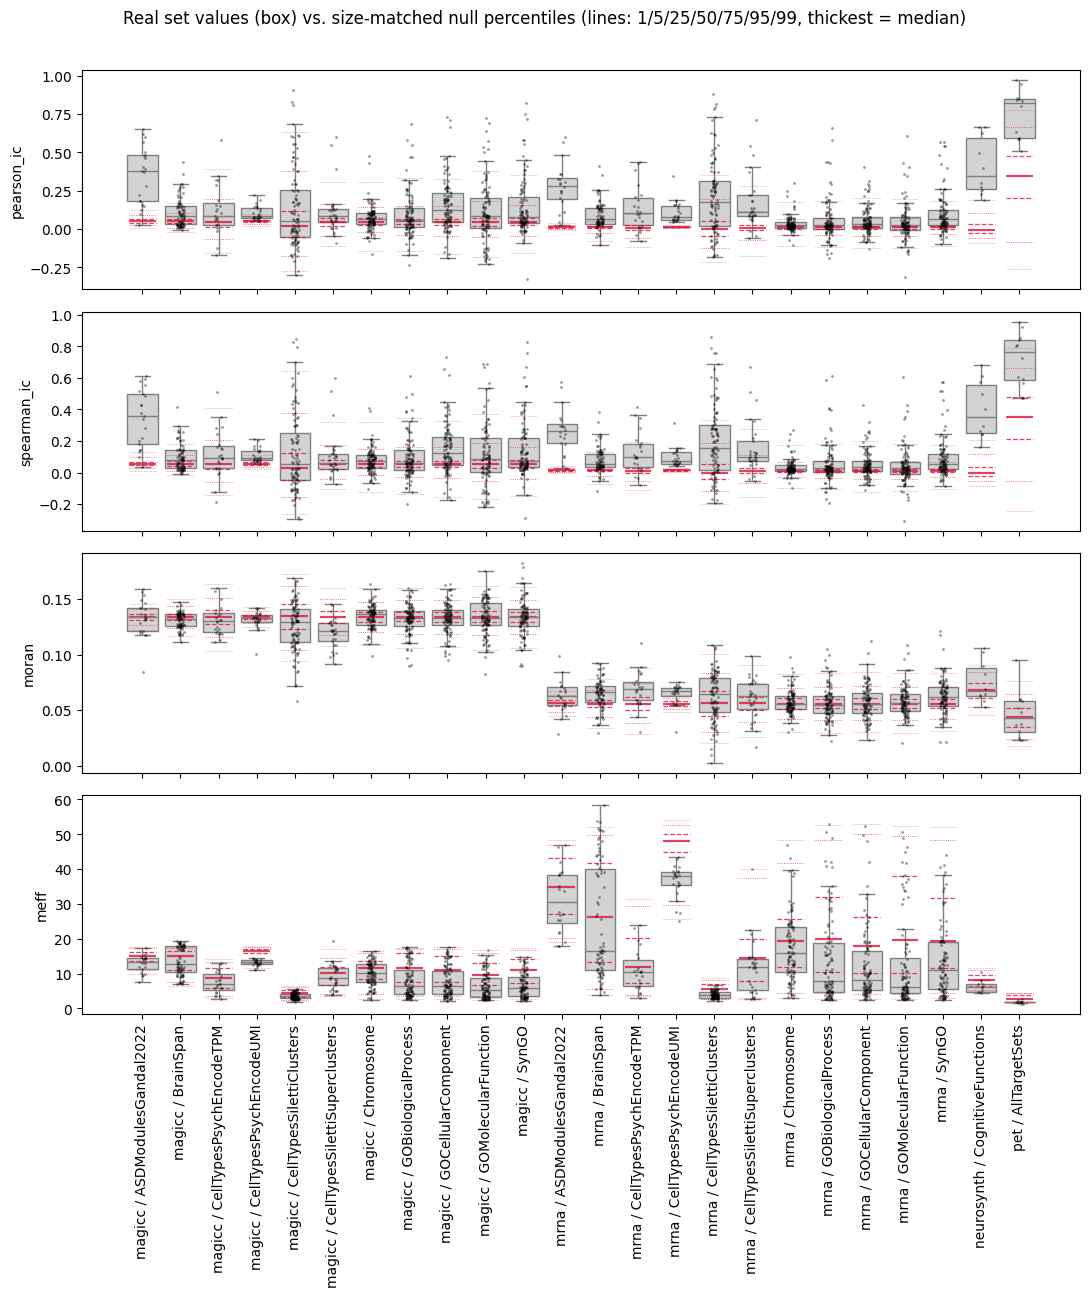

In [4]:
# Real sets' actual metric values (box + strip), compared against the size-matched null sample
# for that condition (reference lines at the null's 1/5/25/50/75/95/99th percentiles) -- rather
# than converting every real set to its own percentile rank first. This keeps the actual scale
# of each metric visible (e.g. how large the gap to the null median really is, not just whether
# it's above/below it) and shows the null's own spread alongside it.
metrics = ["pearson_ic_pct", "spearman_ic_pct", "moran_pct", "meff_pct"]  # used by the next cell
metrics_raw = ["pearson_ic", "spearman_ic", "moran", "meff"]
PCTS = [1, 5, 25, 50, 75, 95, 99]
PCT_STYLE = {1: (0.4, ":"), 5: (0.6, ":"), 25: (0.9, "--"), 50: (1.6, "-"),
             75: (0.9, "--"), 95: (0.6, ":"), 99: (0.4, ":")}

results["condition"] = results["dataset"] + " / " + results["collection"]
order = sorted(results["condition"].unique())

fig, axes = plt.subplots(len(metrics_raw), 1, figsize=(11, 3.2 * len(metrics_raw)), sharex=True)

for ax, metric in zip(axes, metrics_raw):
    sn.boxplot(data=results, x="condition", y=metric, order=order, ax=ax,
               showfliers=False, color="lightgray")
    sn.stripplot(data=results, x="condition", y=metric, order=order, ax=ax,
                 size=2, alpha=0.4, color="black")
    for xi, cond in enumerate(order):
        null_vals = null_pooled[cond][metric].dropna().values
        for p, v in zip(PCTS, np.percentile(null_vals, PCTS)):
            lw, ls = PCT_STYLE[p]
            ax.hlines(v, xi - 0.35, xi + 0.35, color="crimson", lw=lw, ls=ls, alpha=0.8)
    ax.set_ylabel(metric)
    ax.set_xlabel("")

axes[-1].set_xticklabels(axes[-1].get_xticklabels(), rotation=90)
fig.suptitle("Real set values (box) vs. size-matched null percentiles "
             "(lines: 1/5/25/50/75/95/99, thickest = median)", y=1.01)
fig.tight_layout()

,pearson_ic,spearman_ic,moran,meff
condition,,,,
magicc / ASDModulesGandal2022,0.952381,0.904762,0.285714,0.047619
magicc / BrainSpan,0.384615,0.320513,0.025641,0.512821
magicc / CellTypesPsychEncodeTPM,0.347826,0.304348,0.043478,0.043478
magicc / CellTypesPsychEncodeUMI,0.720000,0.680000,0.120000,0.000000
magicc / CellTypesSilettiClusters,0.170000,0.170000,0.040000,0.110000
magicc / CellTypesSilettiSuperclusters,0.310345,0.241379,0.034483,0.310345
magicc / Chromosome,0.180000,0.170000,0.050000,0.040000
magicc / GOBiologicalProcess,0.140000,0.130000,0.050000,0.060000
magicc / GOCellularComponent,0.360000,0.360000,0.050000,0.030000


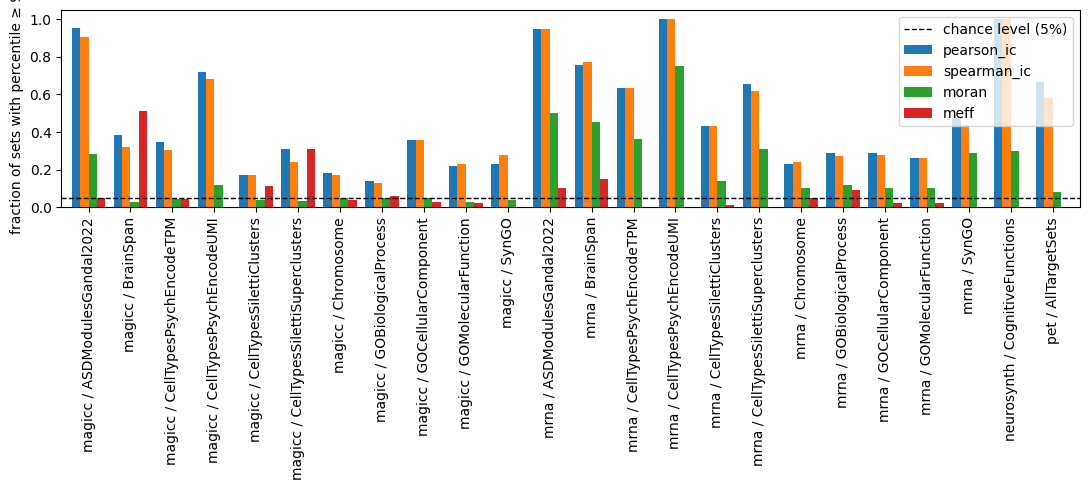

In [5]:
# Fraction of real sets that land above the 95th percentile of their null distribution
# ("clearly elevated" vs. random) -- a direct, quantitative read on the load-bearing premise.
elevated = (
    results.groupby("condition")[metrics]
    .apply(lambda d: (d >= 95).mean())
    .rename(columns=lambda c: c.replace("_pct", ""))
)

fig, ax = plt.subplots(figsize=(11, 5))
elevated.loc[order].plot(kind="bar", ax=ax, width=0.8)
ax.axhline(0.05, ls="--", color="k", lw=1, label="chance level (5%)")
ax.set_ylabel("fraction of sets with percentile ≥ 95")
ax.set_xlabel("")
ax.legend(title=None, loc="upper right")
fig.tight_layout()

elevated.loc[order]

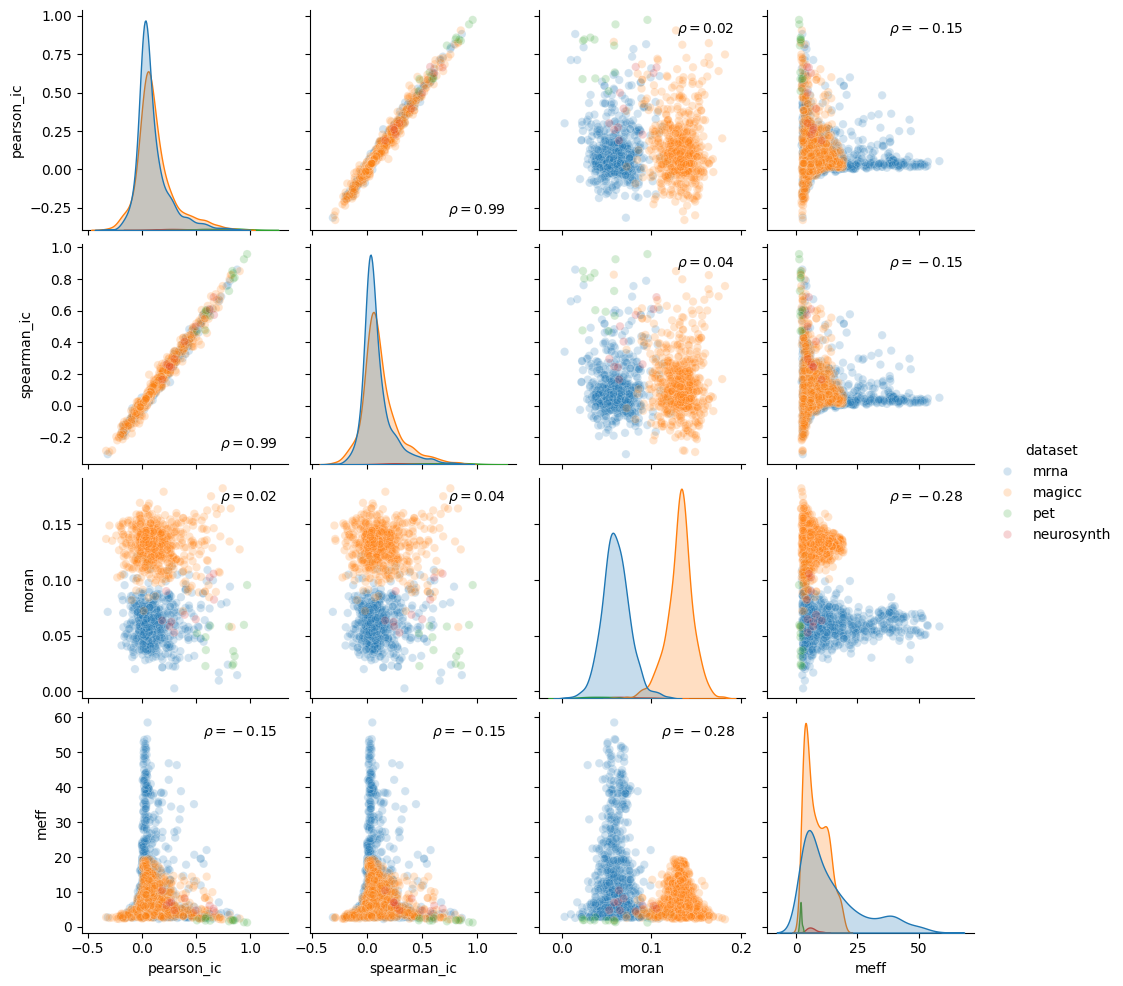

In [6]:
# Are intercorrelation, dimensionality and autocorrelation elevation redundant or independent
# signals? If e.g. pearson_ic_pct and meff_pct are tightly (anti-)correlated across sets, that
# argues against needing both as separate matching features; if not, they carry distinct
# information worth matching on separately later.
plot = sn.pairplot(results[["dataset", "pearson_ic", "spearman_ic", "moran", "meff"]], hue="dataset", plot_kws={"alpha": 0.2})
corr = plot.data.drop(columns="dataset").corr()
for ax, r in zip(plot.axes.ravel(), corr.values.ravel()):
    if r == 1:
        continue
    ax.annotate(
        rf"$\rho = {r:.2f}$", xycoords="axes fraction", 
        **({"xy": (0.95, 0.95), "ha": "right", "va": "top"} if r < 0.5 else {"xy": (0.95, 0.05), "ha": "right", "va": "bottom"})
    )


## Interpretation

Real sets are elevated in within-set intercorrelation vs. a size-matched random background almost 
everywhere, but by how much depends strongly on collection type: compact, biologically-coherent 
sets (`ASDModulesGandal2022`, `CellTypesPsychEncodeUMI`, `BrainSpan`, Neurosynth `CognitiveFunctions`, 
PET `AllTargetSets`) show 60-100% of sets in the top 5% of their null; broad, hierarchically-defined 
categories (GO terms, `Chromosome`, `SynGO`, `CellTypesSilettiClusters`) show only 13-29% -- still 
clearly above the 5% chance level, but far weaker. A XSEA colocalization method, or a intercorrelation-
matched null is clearly motivated.

**Pearson and Spearman intercorrelation are near-interchangeable** (pooled `r = 0.99`) -- the
planned "correlation family follows the colocalization method" rule matters less than assumed in
practice; either family should work as a matching statistic regardless of the eventual
colocalization method.

**Matching must be relative to each background's own distribution, never an absolute threshold.**
MAGICC's background is uniformly more spatially autocorrelated than mrna/pet/neurosynth (bg mean
Moran's I 0.13 vs 0.04-0.07), which visually makes MAGICC's within-set values look "elevated" on
a raw scale -- but relative to *its own* background, MAGICC's within-set Moran's I is flat, not
elevated. The real within-set autocorrelation signal lives in specific mrna marker-gene
collections (`CellTypesPsychEncodeUMI` 75% >=95th pct, `ASDModulesGandal2022` 48%, `BrainSpan`
46%), not in a MAGICC-vs-mrna dataset-level effect. Confirms (does not change) the already-decided
k-NN-within-background design -- an absolute/cross-dataset threshold would have been misleading
here.

**`meff` (effective dimensionality) is consistently lower for real sets** than for random draws,
confirming it tracks a real, related-but-distinct signal. Its relationship to intercorrelation is
dataset-dependent: weak for gene-expression sets (mrna/magicc `r ~ -0.12`, i.e. largely
*independent* information -- two sets can share a mean intercorrelation but differ a lot in
cluster structure/dimensionality), much stronger for PET/Neurosynth (`r ~ -0.6` to `-0.7`, largely
*redundant* with intercorrelation there, consistent with their small, tight backgrounds). Design
implication: `meff` is worth prioritizing as a second matching feature for gene-set collections
first; for PET/Neurosynth, intercorrelation matching alone likely already constrains it.

## Step 3: does this actually translate into inflated FPR, and does a fix work?

The next section tests if the characteristics of real map sets seen above actually translates into
increased FPR in simulated data with known characteristics (H0 true, fixed within-set coherence,
fixed autocorrelation-range). Note that the simulated data currently does not model dimensionality.

**What was tried and shelved**: a GAMBA-style **coexpression/intercorrelation-matched null** was 
designed, implemented, and initially benchmarked here. However, because of long computing time and
insufficient performance, it currently lives in a separate branch. 

**The more promising direction, explored below instead**: joint-model methods (`mlr`, `pls`, ...)
fit *all* set members as predictors of Y simultaneously, rather than aggregating independent
per-member correlations. This has a clean theoretical reason to be robust to the exact mechanism
Fulcher et al. diagnosed: for a fixed OLS design matrix, R^2 under a true null (Y unrelated noise)
follows a `Beta(k/2, (n-k-1)/2)` distribution that depends only on `n` (parcels) and `k` (set
size) -- **not** on how correlated the predictor columns are with each other. If that holds up
empirically, joint-model statistics sidestep the whole false-positive mechanism for free, without
needing any matched-null machinery at all.

> **Scope**: the rest of this notebook is a **testing ground**, not a one-shot final benchmark --
> built to be extended (new methods, coherence levels, set sizes) as more is learned, and to keep
> a written, reproducible record of what's been tried, including open questions not yet resolved.

> **Note:** compute-intensive at the settings below (`N_REP=100`); for a quick smoke-test, lower
> `N_REP` and `N_PERM` in the configuration cell below.


## Synthetic data design

Each background "gene" belongs to a **module** of size `K`: `member = sqrt(w)*shared_signal +
sqrt(1-w)*own_noise`, where `shared_signal` and `own_noise` are independent real GRF maps
(`fetch_reference("grf", ..., collection="ByAlpha")`) -- this keeps realistic spatial
autocorrelation in every map, exactly like the other `bench*` FPR notebooks. `w` is the module's
mean pairwise intercorrelation by construction: any two members of the same module share the same
`shared_signal` term with weight `w`, and since `shared_signal`/`own_noise` are independent
unit-variance (row z-scored) maps, `Cov(member_i, member_j) = w` directly.

One module is the **tested XSEA set** (`w = W_TEST`); the other `N_MODULES - 1` modules serve as
background "camouflage" with their own coherence levels drawn from `W_RANGE`. `Y` is one further,
fully independent GRF draw, so **H0 is true by construction**: any `p < 0.05` is a false
positive, by definition, regardless of `W_TEST` or `ALPHA`.

`W_TEST = 0` is the negative control: with no embedded coherence, the naive null should already be
correctly calibrated (~5% FPR) -- confirming the benchmark itself isn't just generically noisy.


In [7]:
# ── Configuration ─────────────────────────────────────────────────────────────
PARC        = "Yan100"     # single hardcoded parcellation for this whole notebook (100 parcels) --
                            # a clean low-density option (unlike DesikanKilliany, which has some
                            # unusual spatial features). Not part of the automated grid -- change by
                            # hand and rerun to test a different n_obs against the same K_GRID/
                            # n_components below.
ALPHA_GRID  = [0.0, 1.0, 2.0, 3.0]  # GRF smoothness -- same levels as bench1-1
K_GRID      = [10, 20, 30, 50, 100, 200, 300]  # module / tested-set size -- now reaches real
                             # gene-set sizes (up to ~300, see set-size scan above) and, with
                             # PARC="Yan100" (100 parcels), genuinely exceeds n_obs from K=100
                             # onward -- see "N_MODULES vs. K" note below for why this is now
                             # feasible (it wasn't in the first two attempts).
W_RANGE     = (0.05, 0.5)  # background modules' own coherence range (realistic heterogeneity)
W_TEST_GRID = [0.0, 0.1, 0.3, 0.5]   # tested module's coherence: see observed ranges above

# N_MODULES vs. K: build_replicate() draws n_modules*(1+k)+1 *unique* GRF maps per replicate from
# a single alpha's pool. Two earlier attempts at this sweep were both bottlenecked by the GRF
# `ByAlpha` collection only having 1000 maps for alpha in {1,2,3} (10000 for alpha=0.0): scaling
# N_MODULES down to fit large K under that ceiling (down to n_modules=4 at K=200) broke the
# NEGATIVE CONTROL itself (w_test=0 FPR drifted to 9-17% at K=50/n_modules=18, should stay ~5%)
# and got catastrophic at K=200/n_modules=4 (pcr_nc1 FPR up to 0.52, then an outright
# LinAlgError: SVD did not converge inside pcr()'s PCA fit -- itself a symptom of the same root
# problem: too few background modules forces every null candidate to be a near-duplicate,
# multi-modal mix of the same few modules, not a clean random draw). K=20/n_modules=45 stayed
# clean; K=30/n_modules=30 showed only mild drift (negative control 9-16% for a few stats, not
# catastrophic) -- N_MODULES_MIN=30 is set at that validated, still-somewhat-noisy floor.
#
# The `ByAlpha` GRF collection has since been regenerated with 10000 maps at every alpha level
# (was 1000 for alpha in {1,2,3}) -- POOL_CAP below reflects that. This removes the bottleneck for
# nearly the whole realistic K range: N_MODULES now only needs to dip below the original
# N_MODULES_MAX=60 once K exceeds ~150 (9500 // 151 = 62), and only approaches N_MODULES_MIN=30
# at the very top of K_GRID (K=300 -> n_modules=31, essentially the same modest-risk regime
# already characterized at K=30/n_modules=30 above, not new territory).
POOL_CAP = 9500  # margin under the new 10000-per-alpha ceiling
N_MODULES_MAX = 60
N_MODULES_MIN = 30   # empirically-set floor -- see note above

def n_modules_for_k(k, pool_cap=POOL_CAP, max_modules=N_MODULES_MAX, min_modules=N_MODULES_MIN):
    n = pool_cap // (1 + k)
    if n < min_modules:
        raise ValueError(
            f"K={k} would need n_modules={n} < N_MODULES_MIN={min_modules} -- outside the "
            "validated regime (see 'N_MODULES vs. K' note above: lower K, or re-validate the "
            "negative control at a lower N_MODULES_MIN before lowering it)."
        )
    return min(max_modules, n)

# (label, method, colocalize() kwargs, stat) -- multiple labels sharing the same (method, kwargs)
# are computed from a single colocalize()/permute() call (get_p_values() already returns every
# stat for that fit), not re-run per label. Extend freely -- any nispace colocalize() method.
# n_components values above K self-clip inside pcr()/fast_pls1() (both clip against the number of
# predictors), so e.g. "nc20" at K=10 quietly becomes a full-rank fit (~mlr) -- intended, not a
# bug: it lets one fixed set of labels interpolate cleanly across K_GRID without K-conditional
# n_components logic. With K_GRID now reaching 300, nc10/nc20/nc50 all become genuine (non-clipped)
# reductions at the upper K levels, not just at K=30 -- this is now a real test of "how much
# dimensionality reduction is needed to stay calibrated once K is much larger than n_components".
METHOD_VARIANTS = [
    ("pearson",  "pearson", {},                    "rho"),
    ("spearman", "spearman", {},                   "rho"),
    ("mlr_r2",   "mlr", {},                         "r2"),
    ("mlr_beta", "mlr", {},                         "beta"),    # signed, but see note below
    ("pcr_nc1",  "pcr", {"n_components": 1},        "r2"),
    ("pcr_nc1_score_r", "pcr", {"n_components": 1}, "score_r"), # signed, across predictors (c1 only)
    ("pcr_nc2",  "pcr", {"n_components": 2},        "r2"),
    ("pcr_nc5",  "pcr", {"n_components": 5},        "r2"),
    ("pcr_nc10", "pcr", {"n_components": 10},       "r2"),
    ("pcr_nc20", "pcr", {"n_components": 20},       "r2"),
    ("pcr_nc50", "pcr", {"n_components": 50},       "r2"),
    ("pls_nc1",         "pls", {"n_components": 1}, "r2"),
    ("pls_nc1_score_r", "pls", {"n_components": 1}, "score_r"), # signed, across predictors (c1 only)
    ("pls_nc1_weight",  "pls", {"n_components": 1}, "weight"),  # signed, per-predictor -- see note below
    ("pls_nc2",  "pls", {"n_components": 2},        "r2"),
    ("pls_nc5",  "pls", {"n_components": 5},        "r2"),
    ("pls_nc10", "pls", {"n_components": 10},       "r2"),
    ("pls_nc20", "pls", {"n_components": 20},       "r2"),
    ("pls_nc50", "pls", {"n_components": 50},       "r2"),
]
# lasso/ridge/elasticnet deliberately excluded here: they need spatial CV folds, and with no real
# parcellation (parcellation=None throughout this notebook) the only way to run them is a custom
# small-fold split -- even at 5 folds, refitting on every one of N_PERM permutation draws (no fast
# path exists for these methods) costs ~2.5h for this grid, vastly more than everything else here
# combined. Left out of this pass; revisit with a real parcellation + a dedicated, smaller-scale
# run if the large-k / regularization angle becomes a priority.

# NOTE: neither pcr() nor fast_pls1() clip n_components against n_obs (parcel count), only against
# the number of predictors -- nc50 (the highest requested here) stays below n_obs=100 for
# PARC="Yan100", but only just (50/100 = 50% components-to-parcels, a real stress point, not
# margin to spare). It would crash outright on any parcellation with fewer than 50 parcels --
# check against the target n_obs before adding a higher n_components or switching PARC smaller.

# NOTE: mlr's adjusted R2 (`1 - (1-rsq)*(n_obs-1)/(n_obs-n_x-1)`) becomes mathematically degenerate
# once K (= n_x, mlr's predictor count) approaches or exceeds n_obs -- the denominator shrinks
# toward 0 or negative, producing nonsensical values. This is EXPECTED, not a bug: with
# PARC="Yan100" (n_obs=100), K_GRID deliberately reaches K=100/150/200/300, all >= n_obs, to
# observe how badly raw mlr breaks down there, in direct contrast to pcr/pls with a small fixed
# n_components (which stay well-posed regardless of how large K gets, since eigh/SIMPLS only
# ever need n_components <= n_obs, not K <= n_obs) -- this is the core empirical question this
# K extension was built to answer.

# NOTE: this grid is substantially larger than any previous pass (8 K_GRID levels x 18 unique
# method/kwargs calls x 4 ALPHA x 4 W_TEST x N_REP replicates) -- for a first exploratory pass,
# strongly consider lowering N_REP/N_PERM and/or trimming K_GRID/ALPHA_GRID first (see the
# smoke-test note on N_REP below).
N_REP  = 100    # independent replicates per condition -- for a quick smoke-test, set N_REP=10
N_PERM = 300   # null permutations per permute() call
P_THRESH = 0.05
SEED0    = 42
N_PROC   = -1

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from nispace import NiSpace
from nispace.datasets import fetch_reference
from nispace.stats.misc import zscore_df


def _zscore_rows(X):
    return np.asarray(zscore_df(X, along="rows", force_df=False))


grf = fetch_reference("grf", parcellation=PARC, collection="ByAlpha", verbose=False)


## Benchmark design

For every `(method variant, ALPHA, W_TEST, K)` condition, run `N_REP` independent replicates
(fresh background, tested set, and Y each time) against the naive null and record the
false-positive rate (fraction of replicates with `p < P_THRESH`). Method variants sharing the
same underlying `(method, kwargs)` (`mlr_r2`/`mlr_beta`; `pcr_nc1`/`pcr_nc1_score_r`;
`pls_nc1`/`pls_nc1_score_r`/`pls_nc1_weight`) reuse a single `colocalize()`/`permute()` call
rather than refitting.

| axis | values here | extend by |
|---|---|---|
| colocalization method/stat | see `METHOD_VARIANTS` (pearson/spearman/mlr r2+beta/pcr/pls at `n_components` in {1,2,5,10,20,50}, plus pcr/pls `score_r` and pls `weight` at `n_components=1`) | add a `(label, method, kwargs, stat)` tuple |
| GRF smoothness `ALPHA` | 0.0, 1.0, 2.0, 3.0 (same as bench1-1) | add to `ALPHA_GRID` |
| tested-set coherence `W_TEST` | 0.0 (negative control), 0.1, 0.3, 0.5 | add to `W_TEST_GRID` |
| set size `K` | 10, 20, 30, 50, 100, 150, 200, 300 -- now reaches real gene-set sizes and, with `PARC="Yan100"`, genuinely exceeds `n_obs` from `K=100` onward | add to `K_GRID`, but re-validate the negative control first if going past `N_MODULES_MIN` (see configuration cell) |
| parcellation `PARC` | single hardcoded value (`"Yan100"`, 100 parcels -- a clean low-density option, chosen over `DesikanKilliany` which has some unusual spatial features) | change by hand and rerun -- deliberately not part of the automated grid |

**Why sweep `ALPHA`**: the reasoning that joint-model R^2 is invariant to predictor collinearity
assumes i.i.d. residuals -- real spatial autocorrelation (present in every GRF map here once
`ALPHA > 0`) violates that assumption for the *classical* parametric reference distribution. The
*permutation*-based null used throughout this notebook may still self-correct (null candidates
share the same autocorrelation as the real target), but that's an assumption this sweep tests
directly rather than assumes.

**History: why `K_GRID` was first capped at 30, and how it now reaches 300.** Two earlier attempts
both ran into the same bottleneck: the GRF `ByAlpha` collection used to have only 1000 maps for
`alpha in {1,2,3}` (10000 for `alpha=0.0`), and each replicate draws `n_modules*(1+k)+1` *unique*
maps from a single alpha's pool. The first attempt scaled `N_MODULES` down to fit large `K` under
that ceiling (down to `n_modules=4` at `K=200`) -- this was wrong, not just slow: with too few
background modules, a random null draw of `K` genes from the shrunken background pool is forced
(pigeonhole) to pull roughly equal shares from each of the few modules, so every null candidate
ends up internally multi-modal rather than a clean random draw. This **broke the negative control
itself** (`w_test=0` FPR drifted to 9-17% at `K=50`/`n_modules=18`, should stay ~5%) and got
catastrophic at `K=200`/`n_modules=4` (`pcr_nc1` FPR up to 0.52, then an outright
`LinAlgError: SVD did not converge` inside `pcr()`'s PCA fit -- itself a symptom of the same root
cause, not an independent bug). The second attempt capped `K_GRID` at `[10, 20, 30]`, the range
that stayed within a validated `N_MODULES` floor (`K=20`/`n_modules=45` clean; `K=30`/`n_modules=30`
showed only mild drift, not catastrophic) given that 1000-map ceiling.

**The GRF `ByAlpha` collection has since been regenerated with 10000 maps at every alpha level**
(was 1000 for `alpha in {1,2,3}`), removing the bottleneck for nearly the whole realistic range:
`POOL_CAP` in the configuration cell reflects this, so `N_MODULES` now only needs to dip below the
original `N_MODULES_MAX=60` once `K` exceeds ~150, and only approaches the validated
`N_MODULES_MIN=30` floor at the very top of `K_GRID` (`K=300` -> `n_modules=31`, essentially the
same modest-risk regime already characterized at `K=30`/`n_modules=30`, not new territory). This
is what makes it possible to finally test **`K > n_obs`** directly: with `PARC="Yan100"`
(`n_obs=100`), `K_GRID` now includes `K=100/150/200/300`, all at or beyond `n_obs` -- the regime
raw `mlr` is expected to break down in (rank-deficient design matrix, spuriously
inflated/degenerate adjusted R^2 -- see the configuration cell's note), in
direct contrast to `pcr`/`pls` with a small fixed `n_components`, which stay well-posed regardless
of `K` since `eigh`/SIMPLS only ever need `n_components <= n_obs`, not `K <= n_obs`. Confirming
that contrast empirically is the core reason this extension exists.

**`N_MODULES` scales with `K`** (`n_modules_for_k()` in the configuration cell above, with a
validated floor): at `K=10` it reproduces the original fixed `N_MODULES=60` exactly, so those
cells stay directly comparable to every previous run.

**`PARC` is intentionally left as a single hardcoded value, not a grid axis** -- it's the
component-to-parcel *ratio* (and now, with `K_GRID` reaching 300, the `K`-to-parcel ratio too)
that should matter, not either one in isolation, so a full `PARC x K x n_components` grid would be
needed to test that properly, and that's a much larger run than is worth automating here.
`"Yan100"` (100 parcels) was chosen over `"DesikanKilliany"` (68 parcels, the only smaller
commonly-used option) specifically because it's a cleaner functional parcellation, without
DesikanKilliany's unusual spatial features -- swap `PARC` by hand and rerun this section against
the same `K_GRID`/`METHOD_VARIANTS` for any other `n_obs` of interest.

In [8]:
# ── Helper functions ──────────────────────────────────────────────────────────

def build_replicate(w_test, k, n_modules, w_range, alpha, rep_seed):
    '''One synthetic replicate: (background, tested_set, y), H0 true by construction.

    background: (n_modules*k, n_parcels) camouflage pool, own coherence drawn from w_range.
    tested_set: (k, n_parcels), coherence exactly w_test.
    y: (n_parcels,) fully independent GRF draw.
    '''
    pool = grf.loc[f"alpha-{alpha:.1f}"]
    rng = np.random.default_rng(rep_seed)
    n_needed = n_modules * (1 + k) + 1  # (signal + members) per module, + 1 for y
    idx = rng.choice(len(pool), size=n_needed, replace=False)
    Z = _zscore_rows(pool.iloc[idx].to_numpy())
    p = 0
    signals = Z[p:p + n_modules]; p += n_modules
    members_raw = Z[p:p + n_modules * k].reshape(n_modules, k, -1); p += n_modules * k
    y = Z[p]
    ws = rng.uniform(*w_range, size=n_modules)
    ws[0] = w_test  # module 0 is the tested set
    modules = (np.sqrt(ws)[:, None, None] * signals[:, None, :]
               + np.sqrt(1 - ws)[:, None, None] * members_raw)
    tested = modules[0]
    background = modules[1:].reshape(-1, modules.shape[-1])
    return background, tested, y


def extract_p(p_values, stat):
    '''get_p_values() returns a plain DataFrame for single-stat methods, a dict of DataFrames
    for multi-stat methods (mlr/pls/...) -- normalize both to a single float.'''
    if isinstance(p_values, dict):
        return float(p_values[stat].iloc[0, 0])
    return float(p_values.iloc[0, 0])


def run_unique_call(method, kwargs, stats, w_test, k, n_modules, w_range, alpha, n_rep, n_perm,
                     seed0, n_proc=1):
    '''One (method, kwargs, w_test, alpha) condition -> {stat: p-value array}, one entry per
    requested stat from the *same* colocalize()/permute() call (no refitting per stat).'''
    p_by_stat = {stat: np.full(n_rep, np.nan) for stat in stats}

    for rep in range(n_rep):
        rep_seed = seed0 + rep
        background, tested, y = build_replicate(w_test, k, n_modules, w_range, alpha, rep_seed)

        parcel_labels = [f"p{i}" for i in range(tested.shape[1])]
        x_df = pd.DataFrame(tested, index=pd.MultiIndex.from_tuples(
            [("real_set", f"g{i}") for i in range(k)], names=["set", "gene"]), columns=parcel_labels)
        y_df = pd.DataFrame(y[None, :], index=["y0"], columns=parcel_labels)

        nsp = NiSpace(x=x_df, y=y_df, parcellation=None, standardize=False,
                       n_proc=n_proc, verbose=False, return_self=False)
        nsp.fit()
        nsp.colocalize(method=method, xsea=True, verbose=False, **kwargs)
        nsp.permute(what="sets", sets_X_background=background,
                    n_perm=n_perm, seed=rep_seed, verbose=False)
        pv = nsp.get_p_values(verbose=False)
        for stat in stats:
            p_by_stat[stat][rep] = extract_p(pv, stat)

    return p_by_stat


In [9]:
# ── Run all conditions ────────────────────────────────────────────────────────
# group method variants by their shared underlying (method, kwargs) call
calls = {}
for label, method, kwargs, stat in METHOD_VARIANTS:
    key = (method, tuple(sorted(kwargs.items())))
    calls.setdefault(key, {"method": method, "kwargs": kwargs, "labels": []})
    calls[key]["labels"].append((label, stat))

records = []
t0 = time.time()
for (method, _), call in calls.items():
    kwargs = call["kwargs"]
    stats = sorted({stat for _, stat in call["labels"]})
    for k in K_GRID:
        n_modules = n_modules_for_k(k)
        for alpha in ALPHA_GRID:
            for w_test in W_TEST_GRID:
                tc0 = time.time()
                p_by_stat = run_unique_call(method=method, kwargs=kwargs, stats=stats,
                                            w_test=w_test, k=k, n_modules=n_modules,
                                            w_range=W_RANGE, alpha=alpha, n_rep=N_REP,
                                            n_perm=N_PERM, seed0=SEED0, n_proc=N_PROC)
                for label, stat in call["labels"]:
                    fpr = float(np.mean(p_by_stat[stat] < P_THRESH))
                    records.append(dict(label=label, method=method, alpha=alpha, w_test=w_test,
                                         k=k, n_modules=n_modules, fpr=fpr, n=N_REP))
                print(f"{method:10s} {str(kwargs):20s} k={k:3d} (n_modules={n_modules:2d}) "
                      f"alpha={alpha:.1f} w_test={w_test:.2f}  ({time.time()-tc0:.1f}s)  " +
                      "  ".join(f"{lbl}={float(np.mean(p_by_stat[st] < P_THRESH)):.3f}"
                                for lbl, st in call["labels"]))
print(f"total: {time.time()-t0:.1f}s")

results = pd.DataFrame(records)
results.shape


WARNING | 01/08/26 22:44:41 | nispace.api: In the first non-dev release, all NiSpace object methods will return the object itself by default. Set NiSpace(return_self=True) to disable this warning.
pearson    {}                   k= 10 (n_modules=60) alpha=0.0 w_test=0.00  (22.9s)  pearson=0.010
pearson    {}                   k= 10 (n_modules=60) alpha=0.0 w_test=0.10  (6.0s)  pearson=0.150
pearson    {}                   k= 10 (n_modules=60) alpha=0.0 w_test=0.30  (3.3s)  pearson=0.320
pearson    {}                   k= 10 (n_modules=60) alpha=0.0 w_test=0.50  (3.4s)  pearson=0.400
pearson    {}                   k= 10 (n_modules=60) alpha=1.0 w_test=0.00  (3.4s)  pearson=0.050
pearson    {}                   k= 10 (n_modules=60) alpha=1.0 w_test=0.10  (3.3s)  pearson=0.160
pearson    {}                   k= 10 (n_modules=60) alpha=1.0 w_test=0.30  (3.4s)  pearson=0.360
pearson    {}                   k= 10 (n_modules=60) alpha=1.0 w_test=0.50  (3.4s)  pearson=0.490
pearson    {}     

(2128, 8)

## Results: synthetic FPR benchmark

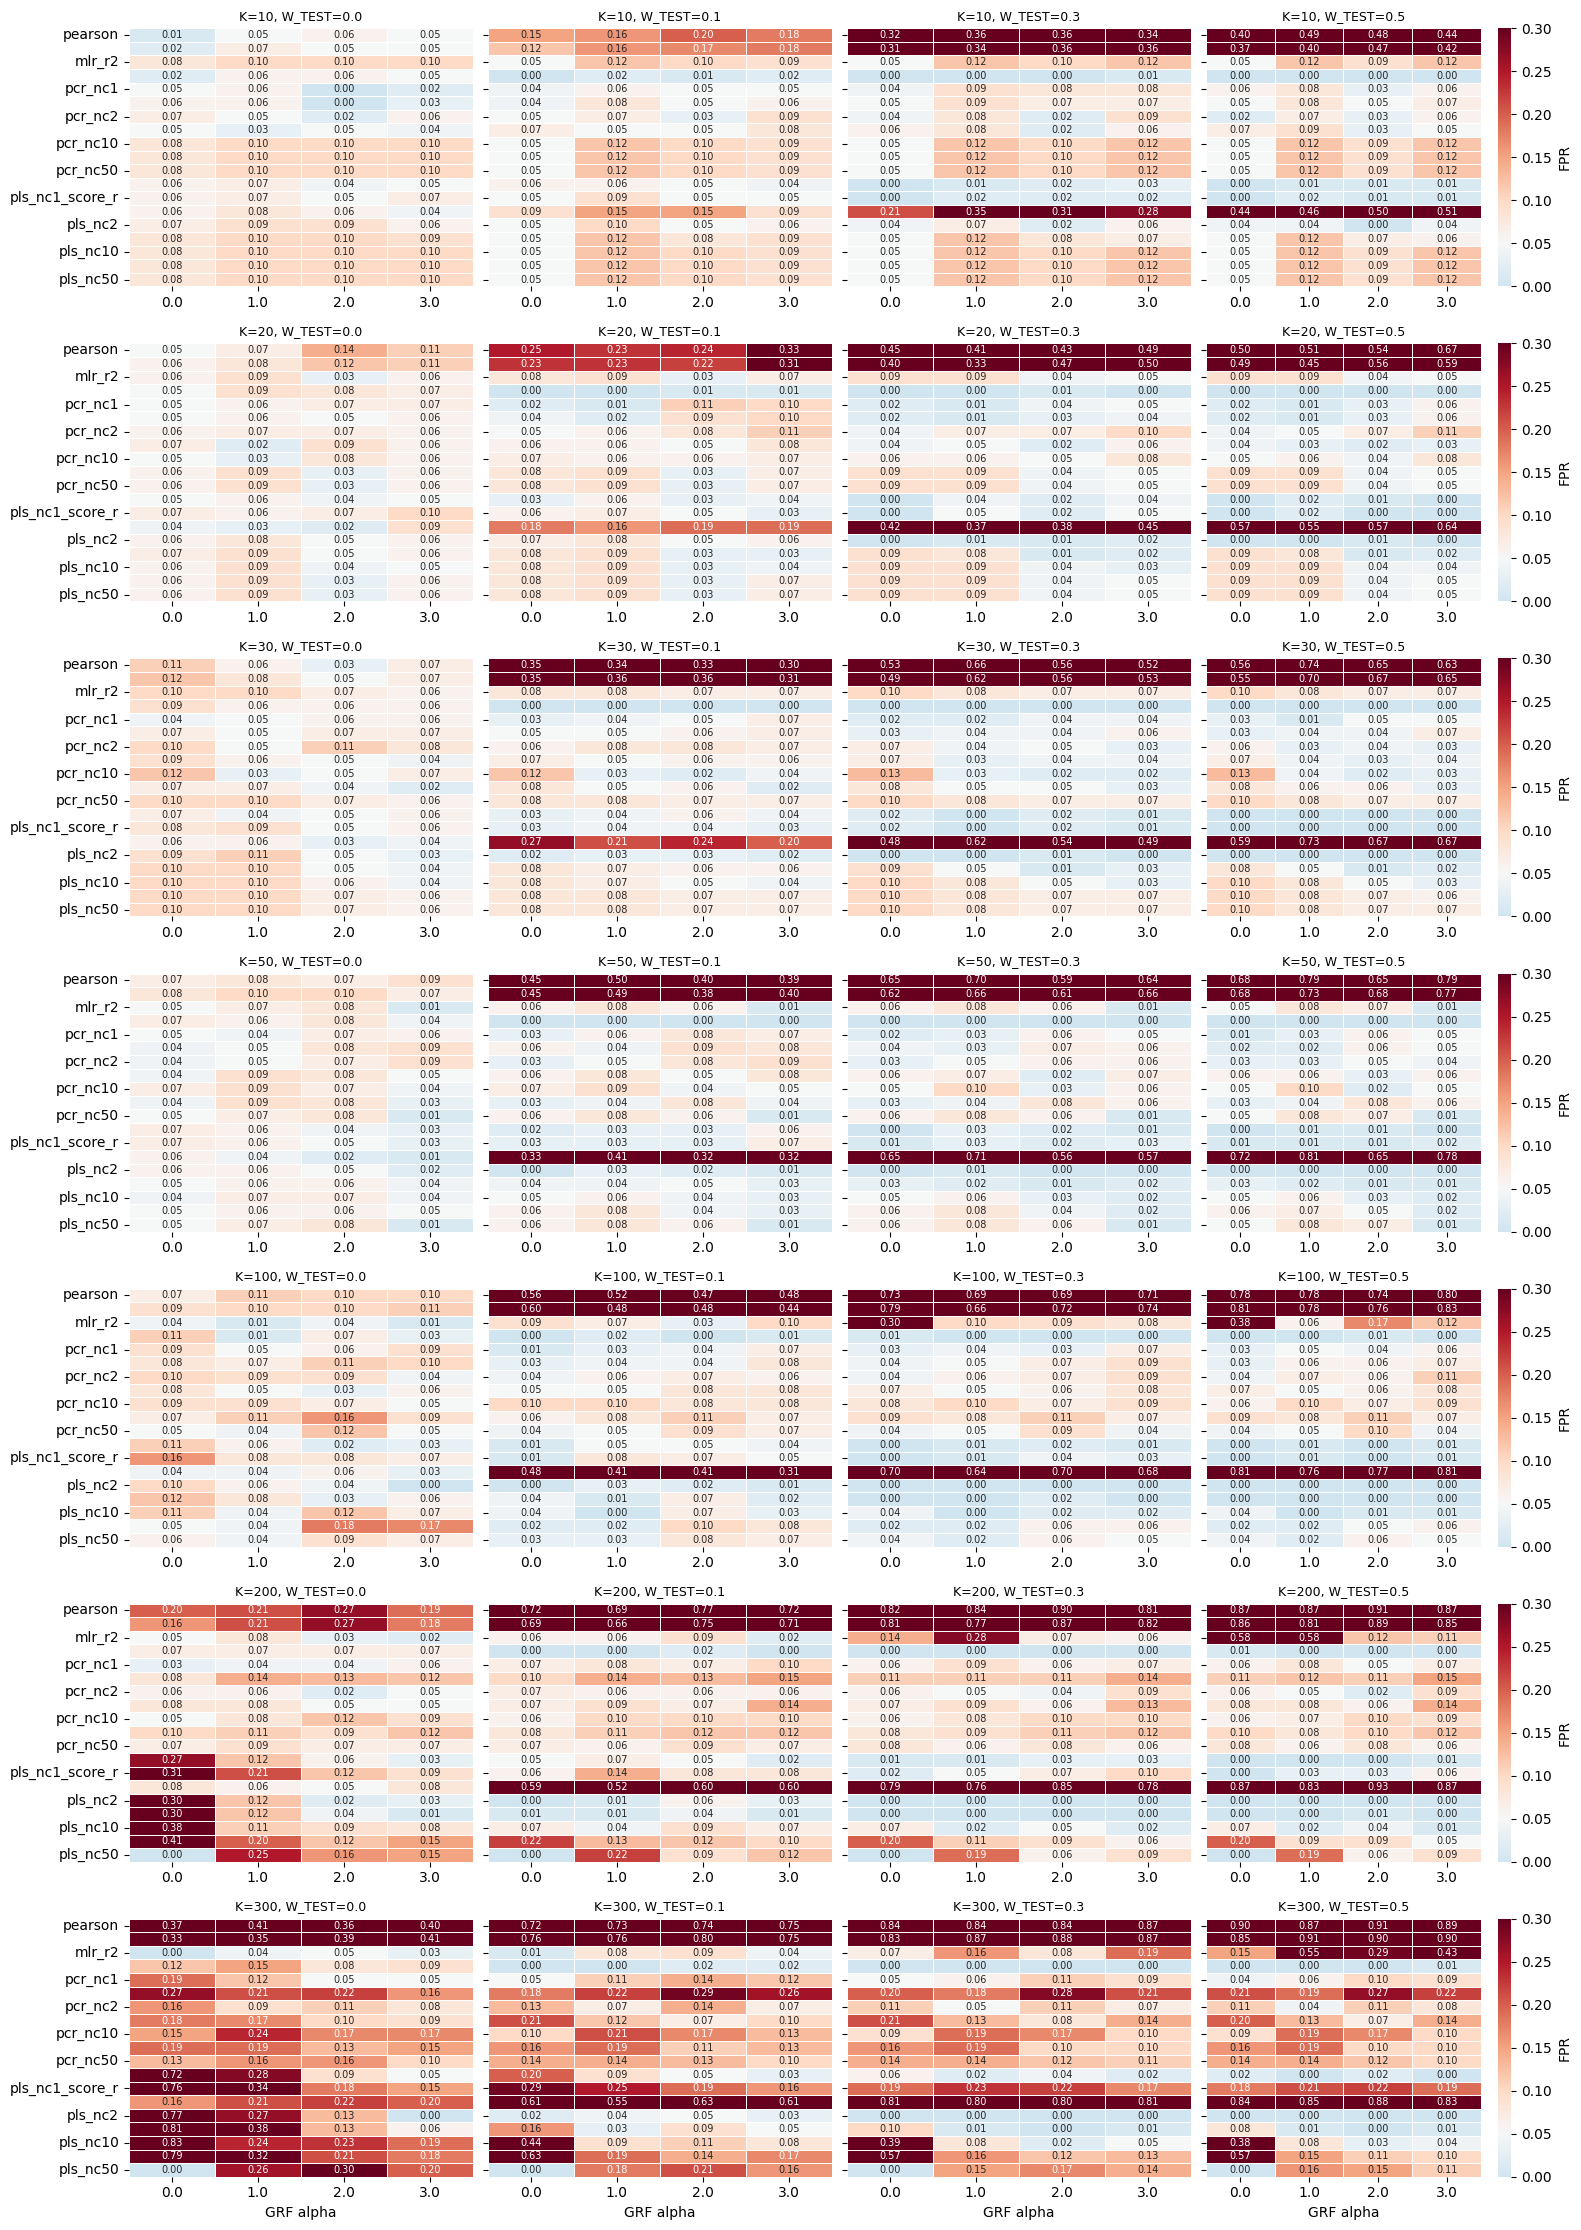

In [10]:
# Heatmap: FPR per (method variant x alpha), one row per K, one column per W_TEST
labels_order = [lbl for lbl, *_ in METHOD_VARIANTS]
fig, axes = plt.subplots(len(K_GRID), len(W_TEST_GRID),
                          figsize=(4 * len(W_TEST_GRID), 3.2 * len(K_GRID)))
axes = np.atleast_2d(axes)
for i, k in enumerate(K_GRID):
    for j, w_test in enumerate(W_TEST_GRID):
        ax = axes[i, j]
        sub = (results[(results.k == k) & (results.w_test == w_test)]
               .pivot(index="label", columns="alpha", values="fpr"))
        sub = sub.loc[labels_order]
        sn.heatmap(sub, ax=ax, annot=True, fmt=".2f", annot_kws={"size": 7}, cmap="RdBu_r",
                   vmin=0, vmax=0.3, center=P_THRESH, linewidths=0.5,
                   cbar=j == len(W_TEST_GRID) - 1,
                   cbar_kws={"label": "FPR"} if j == len(W_TEST_GRID) - 1 else None)
        ax.set_title(f"K={k}, W_TEST={w_test}", fontsize=9)
        ax.set_xlabel("GRF alpha" if i == len(K_GRID) - 1 else "")
        ax.set_ylabel("")
        if j > 0:
            ax.set_yticklabels([])
fig.tight_layout()


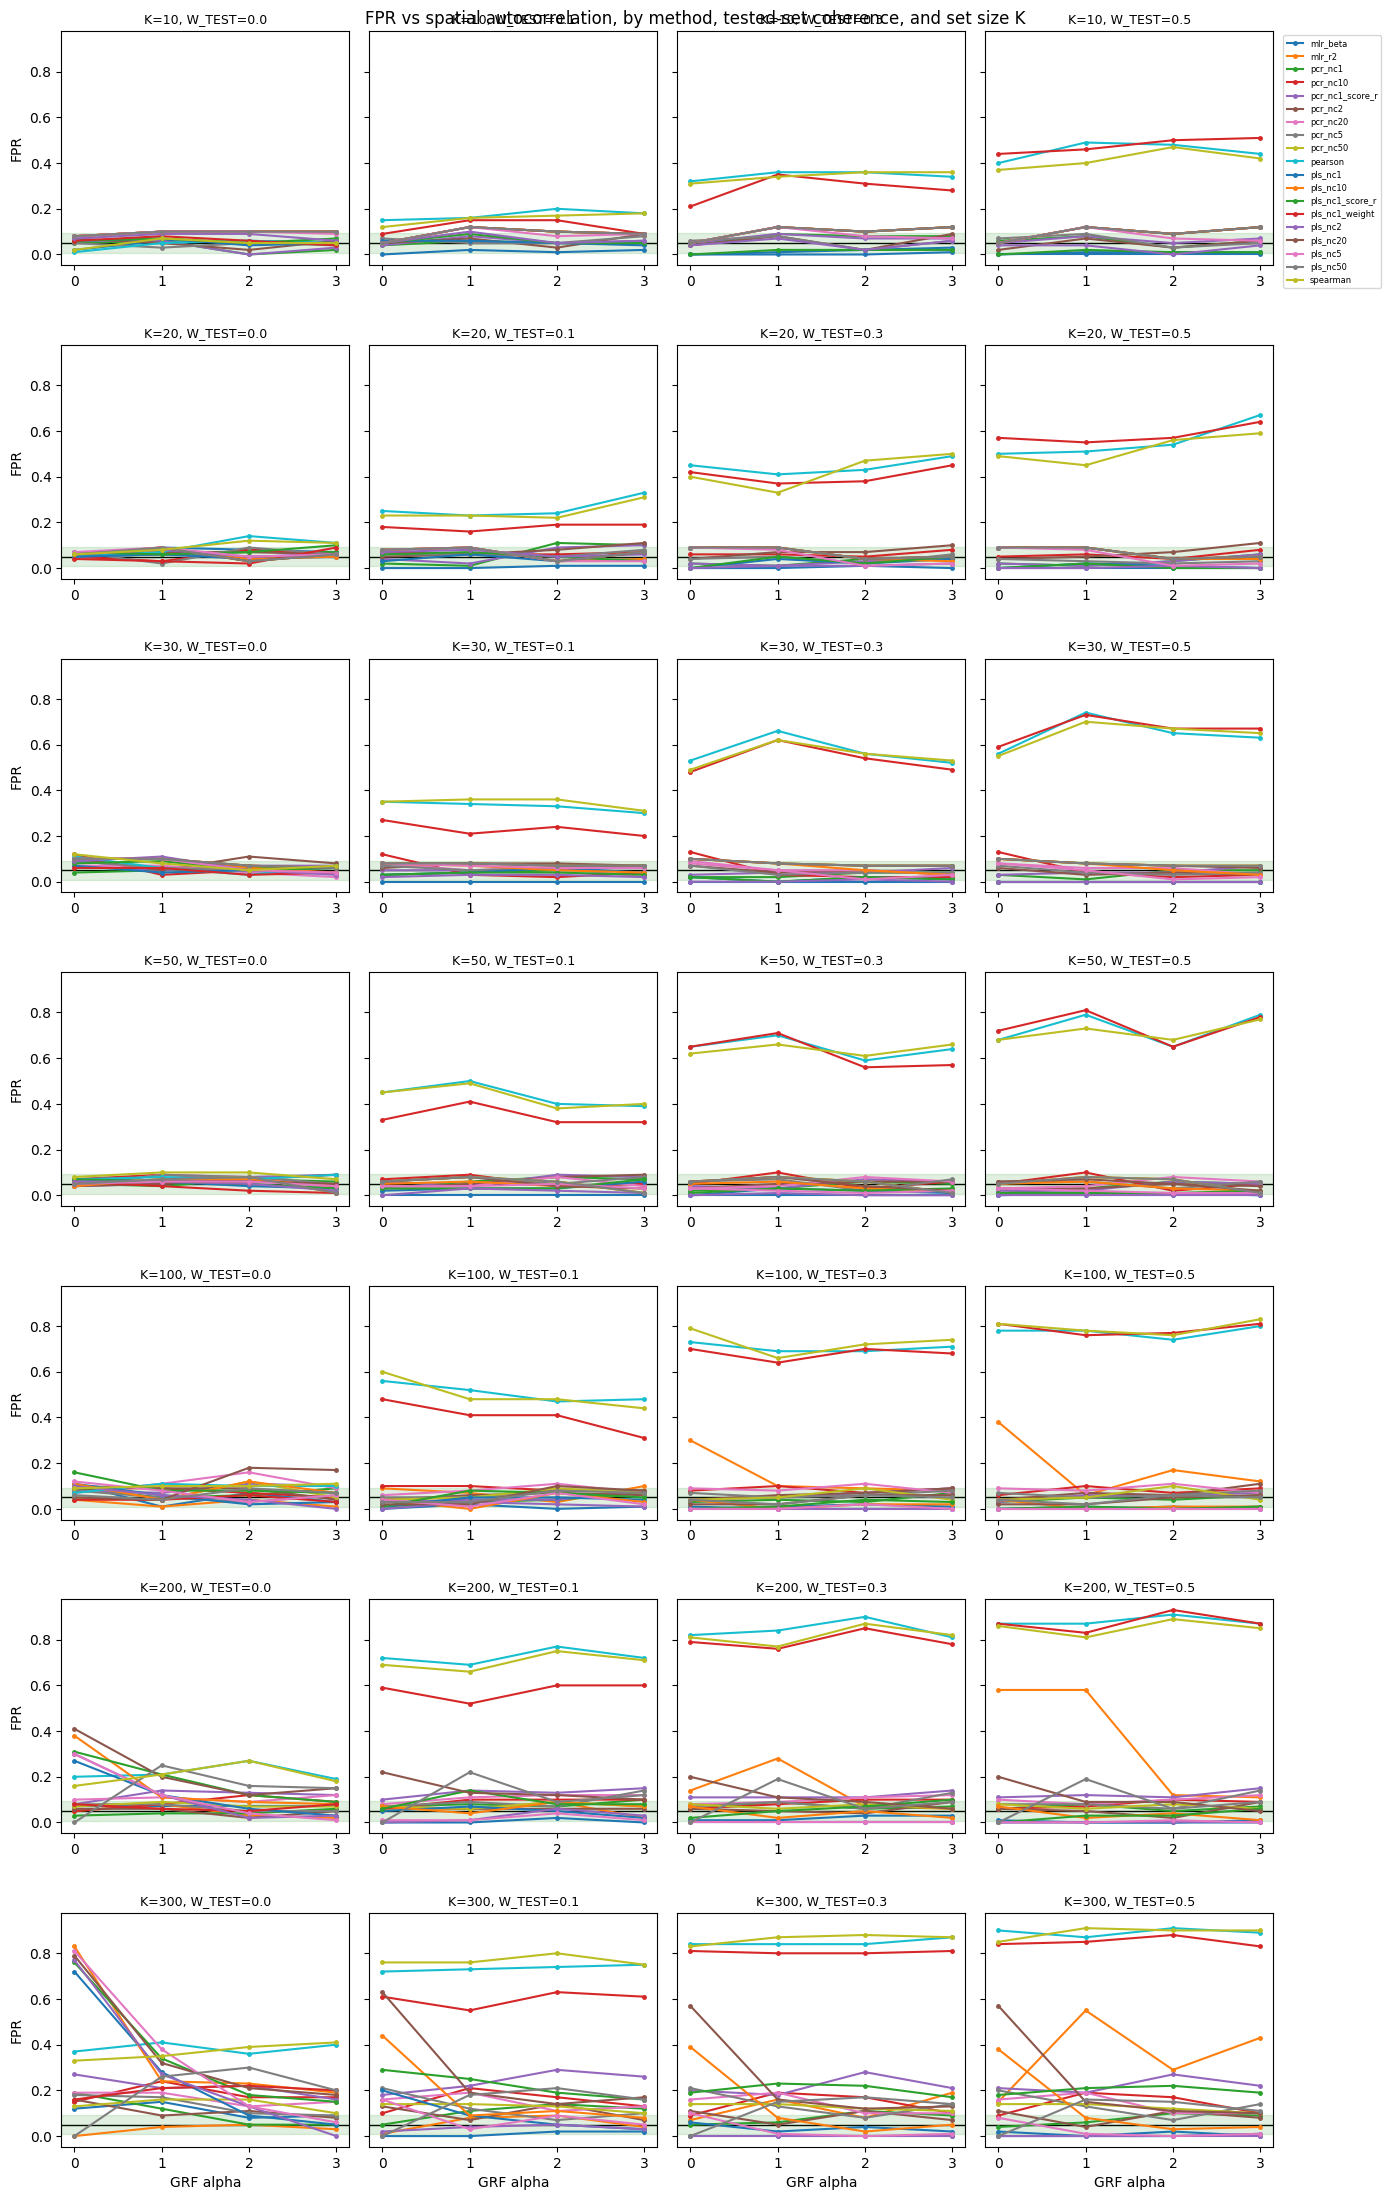

In [11]:
# Line plots: FPR vs alpha, one line per method variant, one panel per (K, W_TEST)
n = int(results["n"].iloc[0])
ci = 1.96 * np.sqrt(P_THRESH * (1 - P_THRESH) / n)

fig, axes = plt.subplots(len(K_GRID), len(W_TEST_GRID),
                          figsize=(3.5 * len(W_TEST_GRID), 3.2 * len(K_GRID)), sharey=True)
axes = np.atleast_2d(axes)
for i, k in enumerate(K_GRID):
    for j, w_test in enumerate(W_TEST_GRID):
        ax = axes[i, j]
        sub = results[(results.k == k) & (results.w_test == w_test)]
        for label, grp in sub.groupby("label"):
            grp = grp.sort_values("alpha")
            ax.plot(grp["alpha"], grp["fpr"], label=label, lw=1.5, marker="o", ms=2.5)
        ax.axhline(P_THRESH, color="k", lw=1, zorder=0)
        ax.axhspan(P_THRESH - ci, P_THRESH + ci, alpha=0.12, color="green", zorder=0)
        ax.set_title(f"K={k}, W_TEST={w_test}", fontsize=9)
        ax.set_xticks(ALPHA_GRID)
        ax.set_xlabel("GRF alpha" if i == len(K_GRID) - 1 else "")
        ax.set_ylabel("FPR" if j == 0 else "")
axes[0, -1].legend(fontsize=6, loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1)
fig.suptitle("FPR vs spatial autocorrelation, by method, tested-set coherence, and set size K",
             fontsize=12)
fig.tight_layout()


In [12]:
results.pivot_table(index=["method", "label", "k"], columns=["w_test", "alpha"], values="fpr")

w_test                  0.0                     0.1                     0.3  \
alpha                   0.0   1.0   2.0   3.0   0.0   1.0   2.0   3.0   0.0   
method   label    k                                                           
mlr      mlr_beta 10   0.02  0.06  0.06  0.05  0.00  0.02  0.01  0.02  0.00   
                  20   0.05  0.09  0.08  0.07  0.00  0.00  0.01  0.01  0.00   
                  30   0.09  0.06  0.06  0.06  0.00  0.00  0.00  0.00  0.00   
                  50   0.07  0.06  0.08  0.04  0.00  0.00  0.00  0.00  0.00   
                  100  0.11  0.01  0.07  0.03  0.00  0.02  0.00  0.01  0.01   
...                     ...   ...   ...   ...   ...   ...   ...   ...   ...   
spearman spearman 30   0.12  0.08  0.05  0.07  0.35  0.36  0.36  0.31  0.49   
                  50   0.08  0.10  0.10  0.07  0.45  0.49  0.38  0.40  0.62   
                  100  0.09  0.10  0.10  0.11  0.60  0.48  0.48  0.44  0.79   
                  200  0.16  0.21  0.27  0.18  0.69  0.66  0.75  0.71  0.81   
                  300  0.33  0.35  0.39  0.41  0.76  0.76  0.80  0.75  0.83   

w_test                                    0.5                    
alpha                   1.0   2.0   3.0   0.0   1.0   2.0   3.0  
method   label    k                                              
mlr      mlr_beta 10   0.00  0.00  0.01  0.00  0.00  0.00  0.00  
                  20   0.00  0.01  0.00  0.00  0.00  0.00  0.00  
                  30   0.00  0.00  0.00  0.00  0.00  0.00  0.00  
                  50   0.00  0.00  0.00  0.00  0.00  0.00  0.00  
                  100  0.00  0.00  0.00  0.00  0.00  0.01  0.00  
...                     ...   ...   ...   ...   ...   ...   ...  
spearman spearman 30   0.62  0.56  0.53  0.55  0.70  0.67  0.65  
                  50   0.66  0.61  0.66  0.68  0.73  0.68  0.77  
                  100  0.66  0.72  0.74  0.81  0.78  0.76  0.83  
                  200  0.77  0.87  0.82  0.86  0.81  0.89  0.85  
                  300  0.87  0.88  0.87  0.85  0.91  0.90  0.90  

[133 rows x 16 columns]

## Interpretation

**1. Naive-null FPR inflation for correlation-aggregation methods scales monotonically with set
coherence AND set size, across the full spatial-autocorrelation range.** At `W_TEST=0` (negative
control), `pearson`/`spearman` stay near nominal (5-8%) at small `K`. From there FPR climbs
steadily with both `W_TEST` and `K` -- at `K=300` it reaches 0.7-0.9 at `W_TEST=0.5`, and even the
negative control itself (`W_TEST=0`) drifts up to 0.2-0.4 purely from `K` growing, since larger
`K` forces more within-module reuse in the resampled background. Not a threshold effect at one
particular `w` or `K` -- a smooth, compounding function of both.

**2. `mlr`'s joint R² -- previously the standout recommendation -- breaks down completely once
`K>=n_obs`, exactly the regime this K-extension was built to test.** Raw R² trivially hits `1.0`
once predictor count reaches sample count (perfect interpolation); the adjusted-R² correction
(`1-(1-R²)(n_obs-1)/(n_obs-nx-1)`) is mathematically undefined right at that boundary and
saturates near `1.0` too, instead of blowing up -- for **both** the real tested set and every null
draw (directly verified: at `K=300`, tested and 5/5 null draws all gave exactly `adj_r2=1.0`).
With real and null pinned to an identical ceiling, there's no discriminative signal left at all --
`mlr_r2`'s earlier "most stable statistic" verdict only held within the narrow `K=10` regime it
was originally measured under, and is now superseded.

**3. `mlr_beta` is not a usable substitute for directionality, and collapses fast.** Already at
`W_TEST=0.1` it drops to **0.00 FPR at every alpha**, and stays there through `W_TEST=0.5`.
Multicollinearity among a truly coherent set's members forces them to share credit for the same
explained variance, shrinking each individual `beta`. Remains fine to report *descriptively*,
never as its own significance test. With `mlr` no longer the recommended joint-model default (see
point 2), this is now a secondary finding rather than an open design question -- `pcr`'s stat list
has no per-predictor coefficient at all, sidestepping the problem entirely (see point 6).

**4. `pls` (any fixed `n_components`) has two separate, serious failure mechanisms once `K>n_obs`
-- the K-extension's single most important new finding, and a direct reversal of the earlier
"prefer more components" guidance below.**
- *Ceiling/saturation collapse* at large `n_components` (e.g. `nc=50` with `n_obs=100`): both real
  and null R² saturate at ~0.9999999... (residual ~1e-8 to 1e-10) regardless of true signal --
  verified directly, `pcr_nc50` on identical X/y gave a real, meaningful R²=0.68-0.76, `pls_nc50`
  on the *same* X/y gave 0.99999998-1.0 for every draw. FPR at `K=200/300`, `alpha=0`: exactly
  0.000 across *every* `W_TEST` (0 through 0.5) -- total power loss, not just miscalibration.
- *Asymmetric overfitting-capacity collapse*, present even at small `nc` (1, 2, 5): FPR
  *decreases* toward 0.00 as `W_TEST` **rises** -- backwards from every other method here, and
  from what the original point 4 (below) described at `K=10`. E.g. `pls_nc2` at `K=300`: FPR 0.77
  at `W_TEST=0`, 0.00 at `W_TEST>=0.3`. Mechanism: PLS's first weight is `w1 ∝ X'y`, a
  covariance-weighted combination across K columns -- how much it can overfit Y depends on how
  much genuinely independent per-column noise is available. A null draw mixes members from many
  mutually-uncorrelated background modules and keeps its full overfitting capacity regardless of
  `W_TEST` (null composition never depends on it); the *tested* set's own capacity shrinks by
  `sqrt(1-W_TEST)` per column as its internal coherence rises (less true idiosyncratic noise
  "material" per member to chase Y with). The tested set falls further and further below the
  null's typical value as `W_TEST` grows -- exactly backwards, since this is precisely the regime
  (real, coherent sets) XSEA is meant to detect.

`pcr` is immune to both mechanisms -- its components are chosen from X's own variance, blind to Y,
so there's no Y-covariance-weighted step for either one to exploit.

**5. `pcr` doesn't share `pls`'s failure modes, but has its own, different problem: an escalating
bias with `n_components` that reverses "more components is safer" and settles on `n_components=2`
(not 5, not a value scaled to the parcellation) as the best default.** Null-draw mean adjusted-R²
(pure noise, should be ~0) at `K=300`,`alpha=0`: `nc=1→0.012, nc=2→0.020, nc=5→0.051, nc=10→0.081,
nc=20→0.136, nc=50→0.477` -- climbing far above zero well before `nc` reaches `n_obs`. The
adjusted-R² correction assumes "generic", roughly-independent regressor directions; PCA components
stop being generic once `nc` approaches the *real* effective rank of a background pool that's
forced to reuse only `n_modules-1≈30` distinct modules at `K=300` (not the nominal `n_obs=100`) --
components start capturing genuine, reproducible structure in a low-effective-rank, resampled-with
-reuse background, which the correction under-corrects for. Net effect on FPR is non-monotonic in
`nc` (worst at `nc=10-20`, mean FPR ~0.15 at `K=300`; better at both `nc=1-2`, ~0.09-0.10, and
`nc=50`, ~0.13, since at the extremes either the effect hasn't kicked in yet or both tested/null
are pushed up together and partially cancel). **`nc=1`/`nc=2` are consistently the best-calibrated
choice across the entire K range tested, including small K where it barely mattered before** --
this directly reverses the original point 4's "keeping more components mitigates the undershoot"
conclusion, which was only true within the `K=10`-fixed regime it was measured under; once `K`
genuinely varies and can exceed `n_obs`, the opposite is closer to true.

**6. `score_r`'s sign fix (median-vote convention, see [[project_pls_colocalization_outputs]]) is
confirmed not to have touched calibration.** `pcr_nc1_score_r`/`pls_nc1_score_r` track their
respective `r2` companions closely at every `(ALPHA, W_TEST)` cell -- including `pls`'s collapse
in point 4 -- exactly as expected, since `score_r**2 == r2` at `n_components=1` and the sign
convention is provably a reporting-only transform.

**Updated practical recommendation (supersedes the `mlr_r2`-based one from the original `K=10`
pass): default to `pcr` with a small, fixed `n_components=2` for XSEA-style set testing under
`what="sets"` resampling.** It's the only joint-model method here that stays reasonably calibrated
across the *entire* tested range (`K=10` to `300`, `alpha=0` to `3`, `W_TEST=0` to `0.5`) --
`mlr` saturates once `K>=n_obs`, `pls` fails in two separate ways once `K>n_obs` (one of them in
exactly the high-coherence regime XSEA exists to detect), and `pcr` itself only stays well-behaved
at small, fixed `nc` -- do **not** scale `n_components` up with the parcellation size or with `K`,
that was the wrong intuition and this benchmark is what corrected it. `score_r` (`pcr`, any
`n_components`) remains the signed alternative when set-level directionality is needed, though its
own calibration degrades somewhat faster than plain `r2` as `K` grows (K=100: FPR 0.064 vs
`r2`'s 0.049; K=300: 0.223 vs 0.089) -- worth keeping in mind if directionality is required at
large `K` specifically. `mlr_beta`/`pls_weight` remain unusable for XSEA significance testing at
any coherence level -- when per-predictor directionality (not just a set-level signed score) is
needed, fall back to a univariate/directional method (`pearson`/`spearman`) with `what="maps"`
(phenotype permutation, already NiSpace's default and already robust to this specific bias per
Fulcher et al.), or prefer subject/group-level permutation (`what="groups"`) over either whenever
the data supports it.